# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [1]:
import math
import re
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# a próxima linha fornece gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn-v0_8')

In [3]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Carregar Dados

In [4]:
df_reviews = pd.read_csv('../Data/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
print(df_reviews.head())

      tconst title_type primary_title original_title  start_year end_year  \
0  tt0068152      movie             $              $        1971       \N   
1  tt0068152      movie             $              $        1971       \N   
2  tt0313150      short          '15'           '15'        2002       \N   
3  tt0313150      short          '15'           '15'        2002       \N   
4  tt0313150      short          '15'           '15'        2002       \N   

  runtime_minutes  is_adult              genres  average_rating  votes  \
0             121         0  Comedy,Crime,Drama             6.3   2218   
1             121         0  Comedy,Crime,Drama             6.3   2218   
2              25         0  Comedy,Drama,Short             6.3    184   
3              25         0  Comedy,Drama,Short             6.3    184   
4              25         0  Comedy,Drama,Short             6.3    184   

                                              review  rating   sp  pos  \
0  The pakage impl

## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

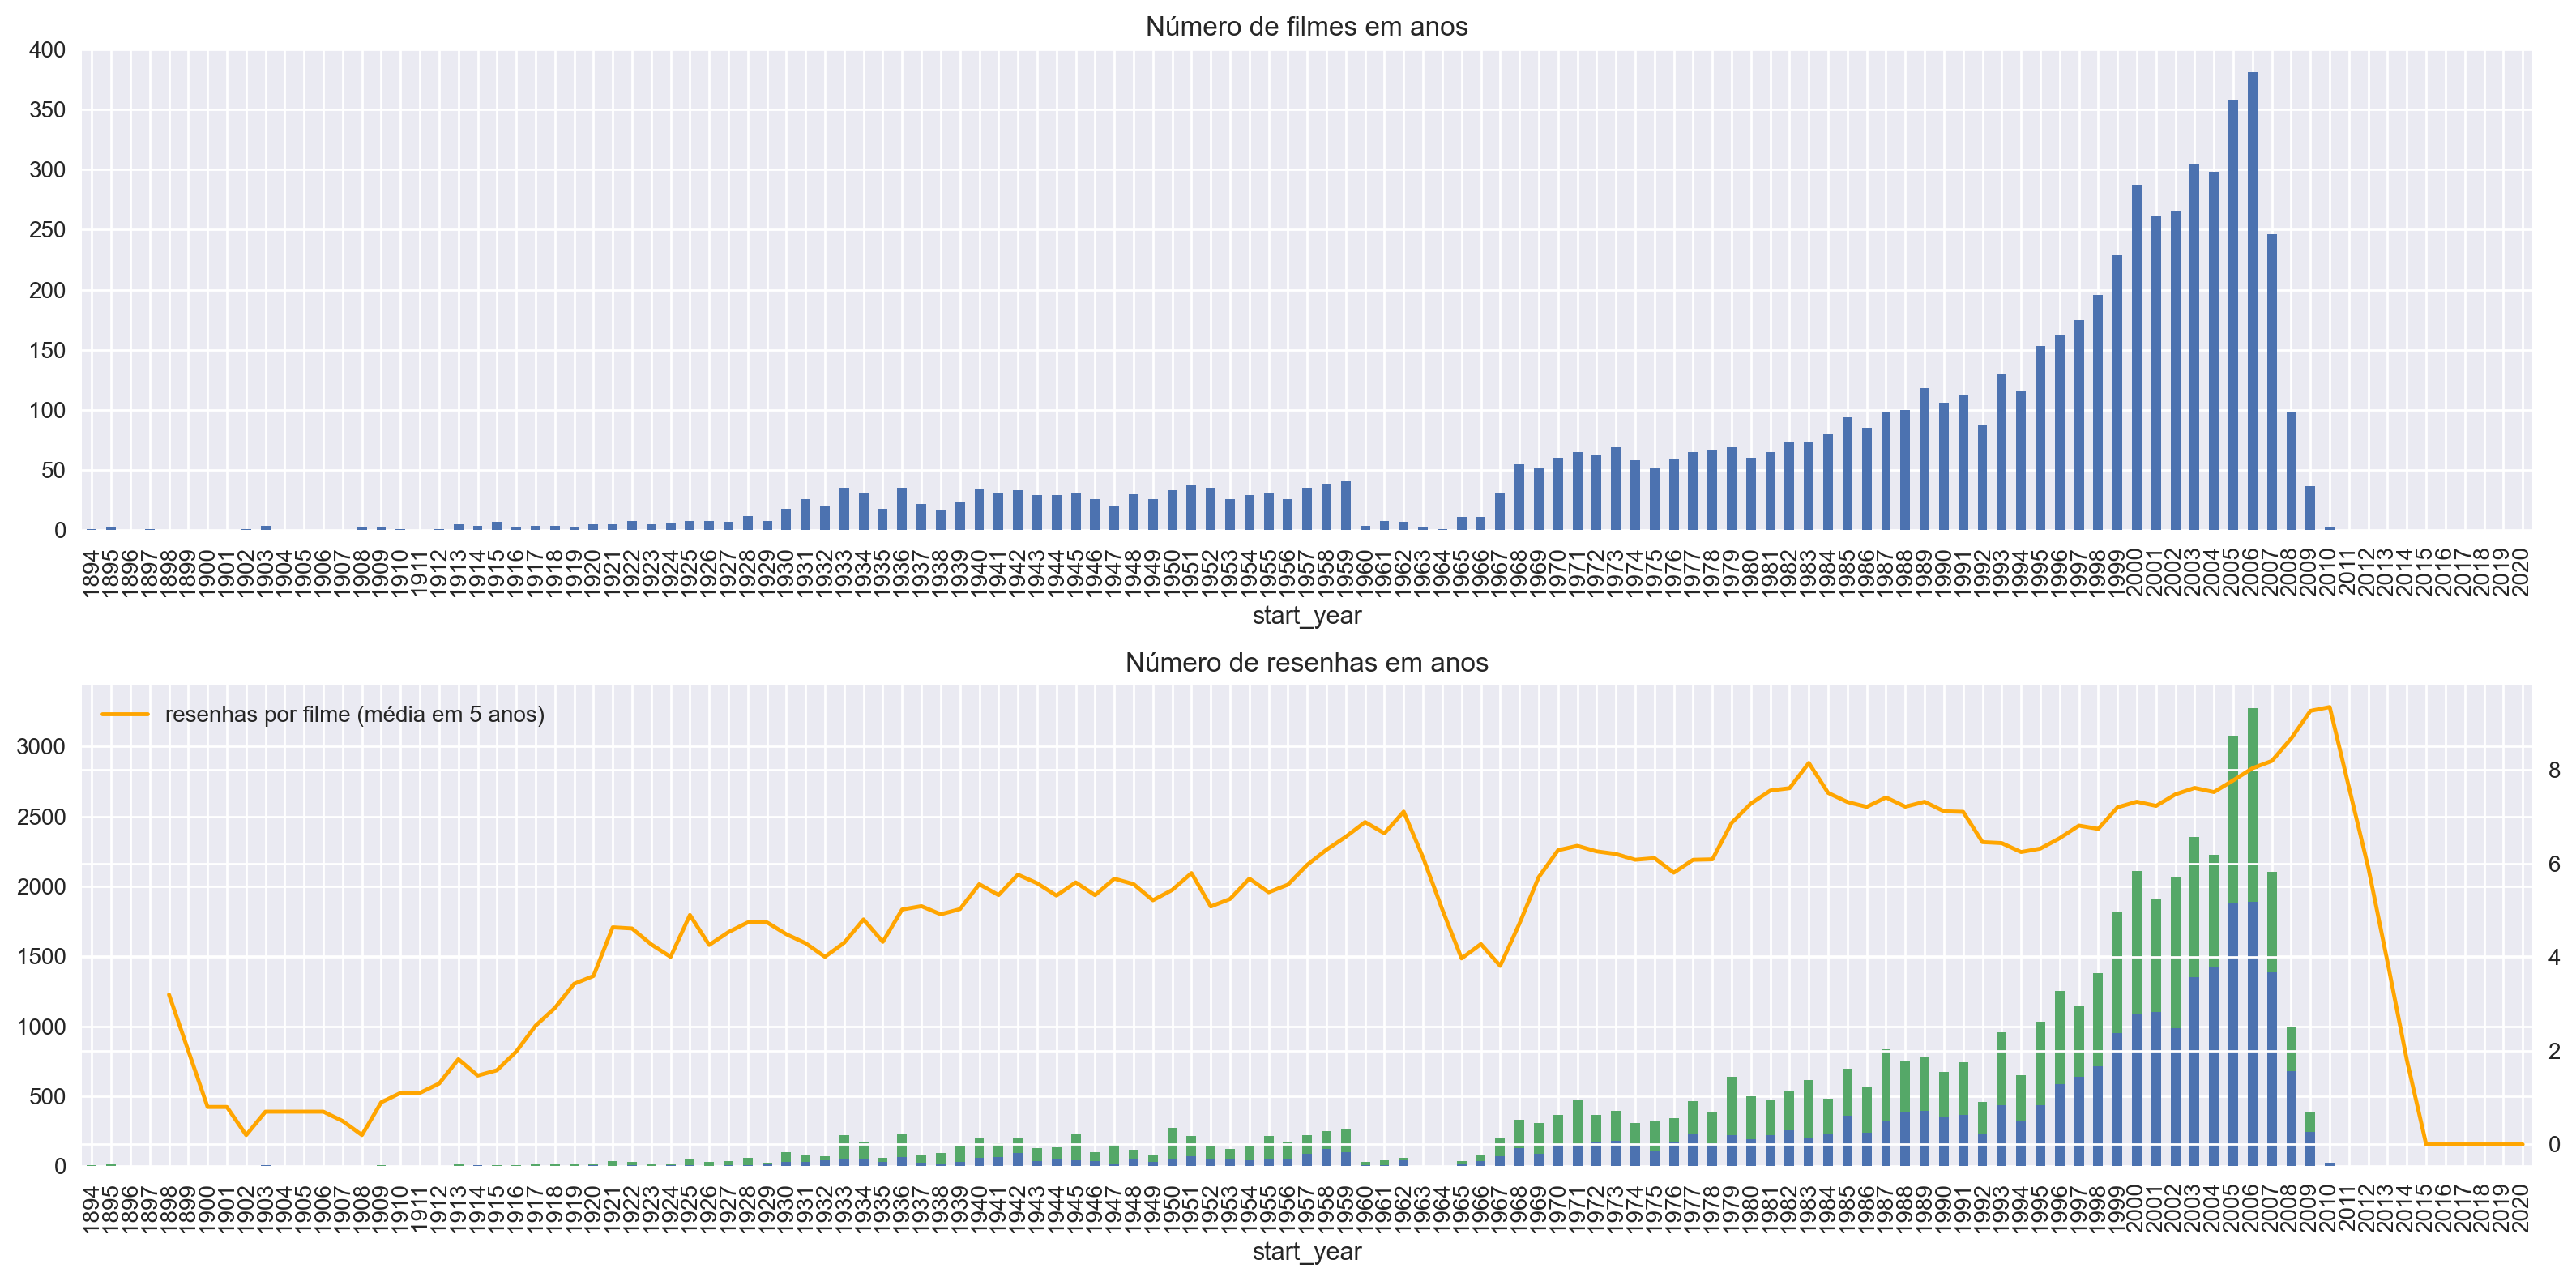

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

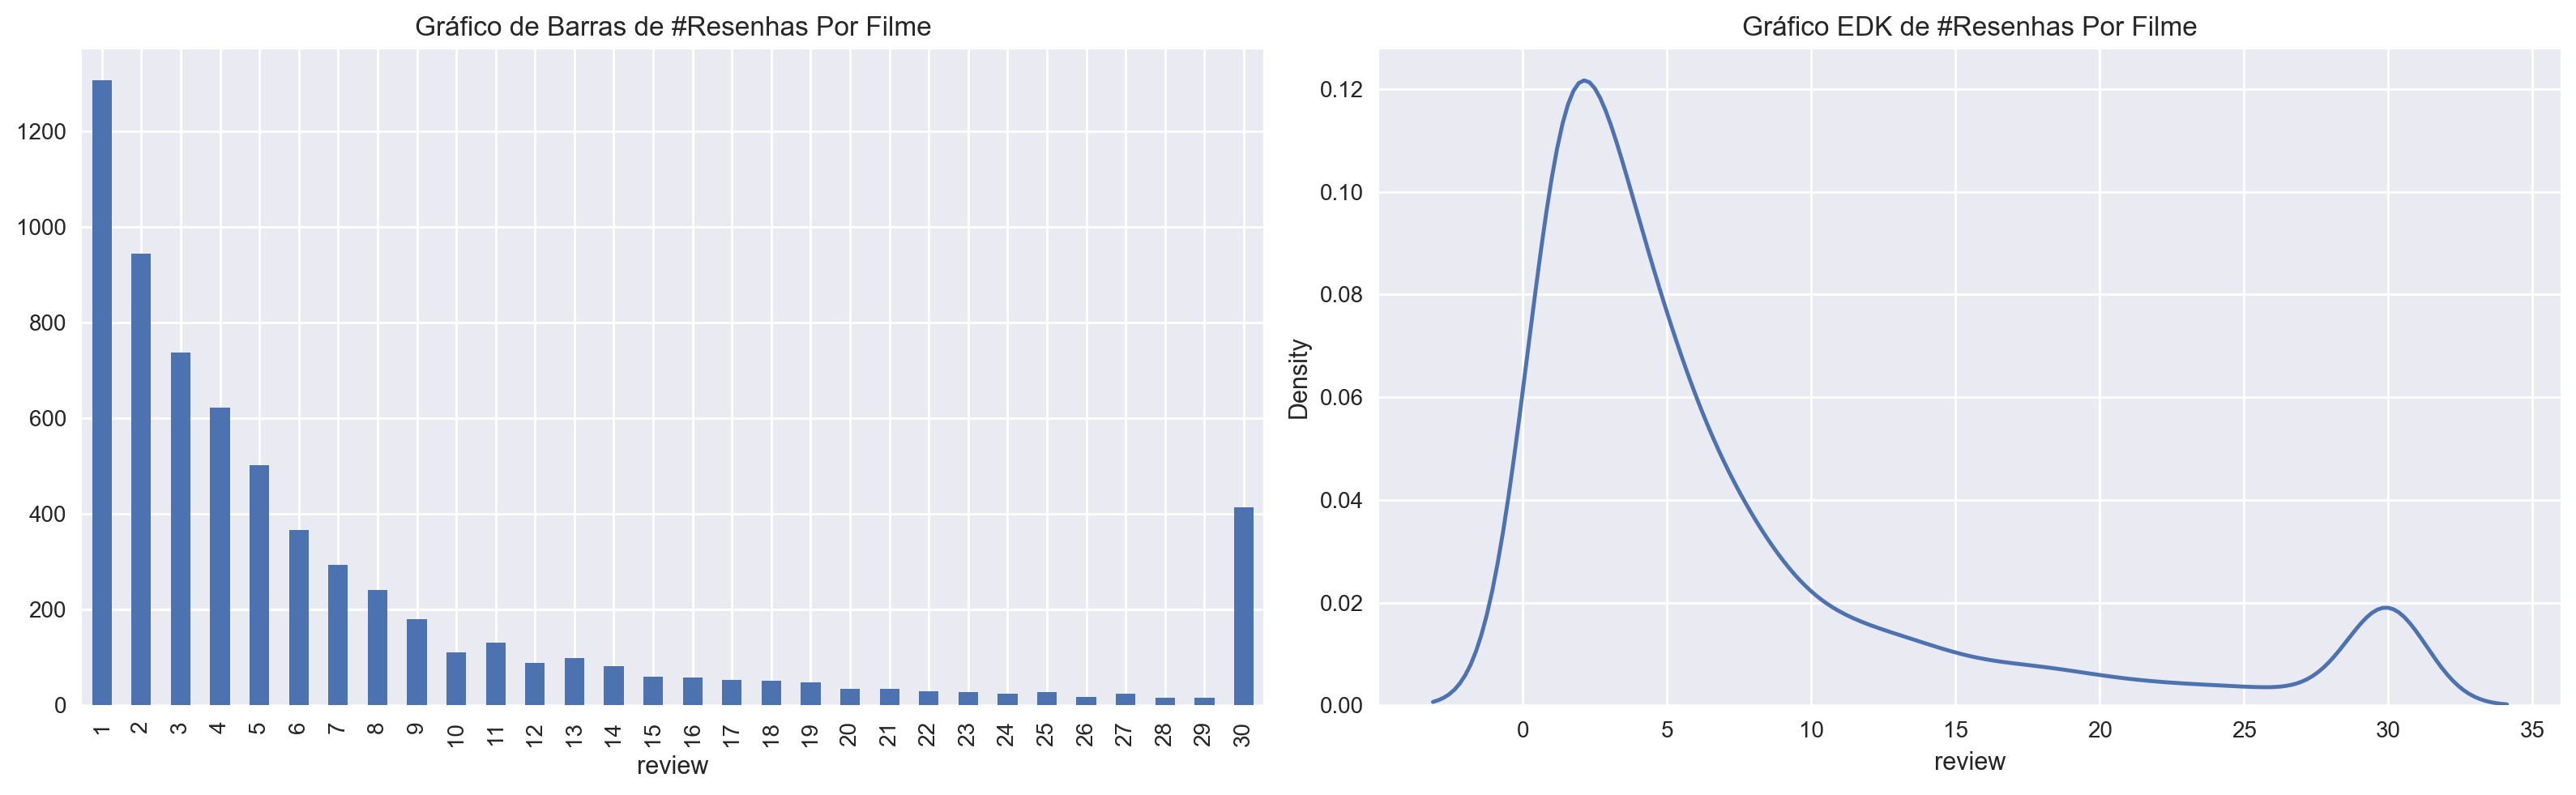

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de #Resenhas Por Filme')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico EDK de #Resenhas Por Filme')

fig.tight_layout()

In [8]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23616
Name: count, dtype: int64

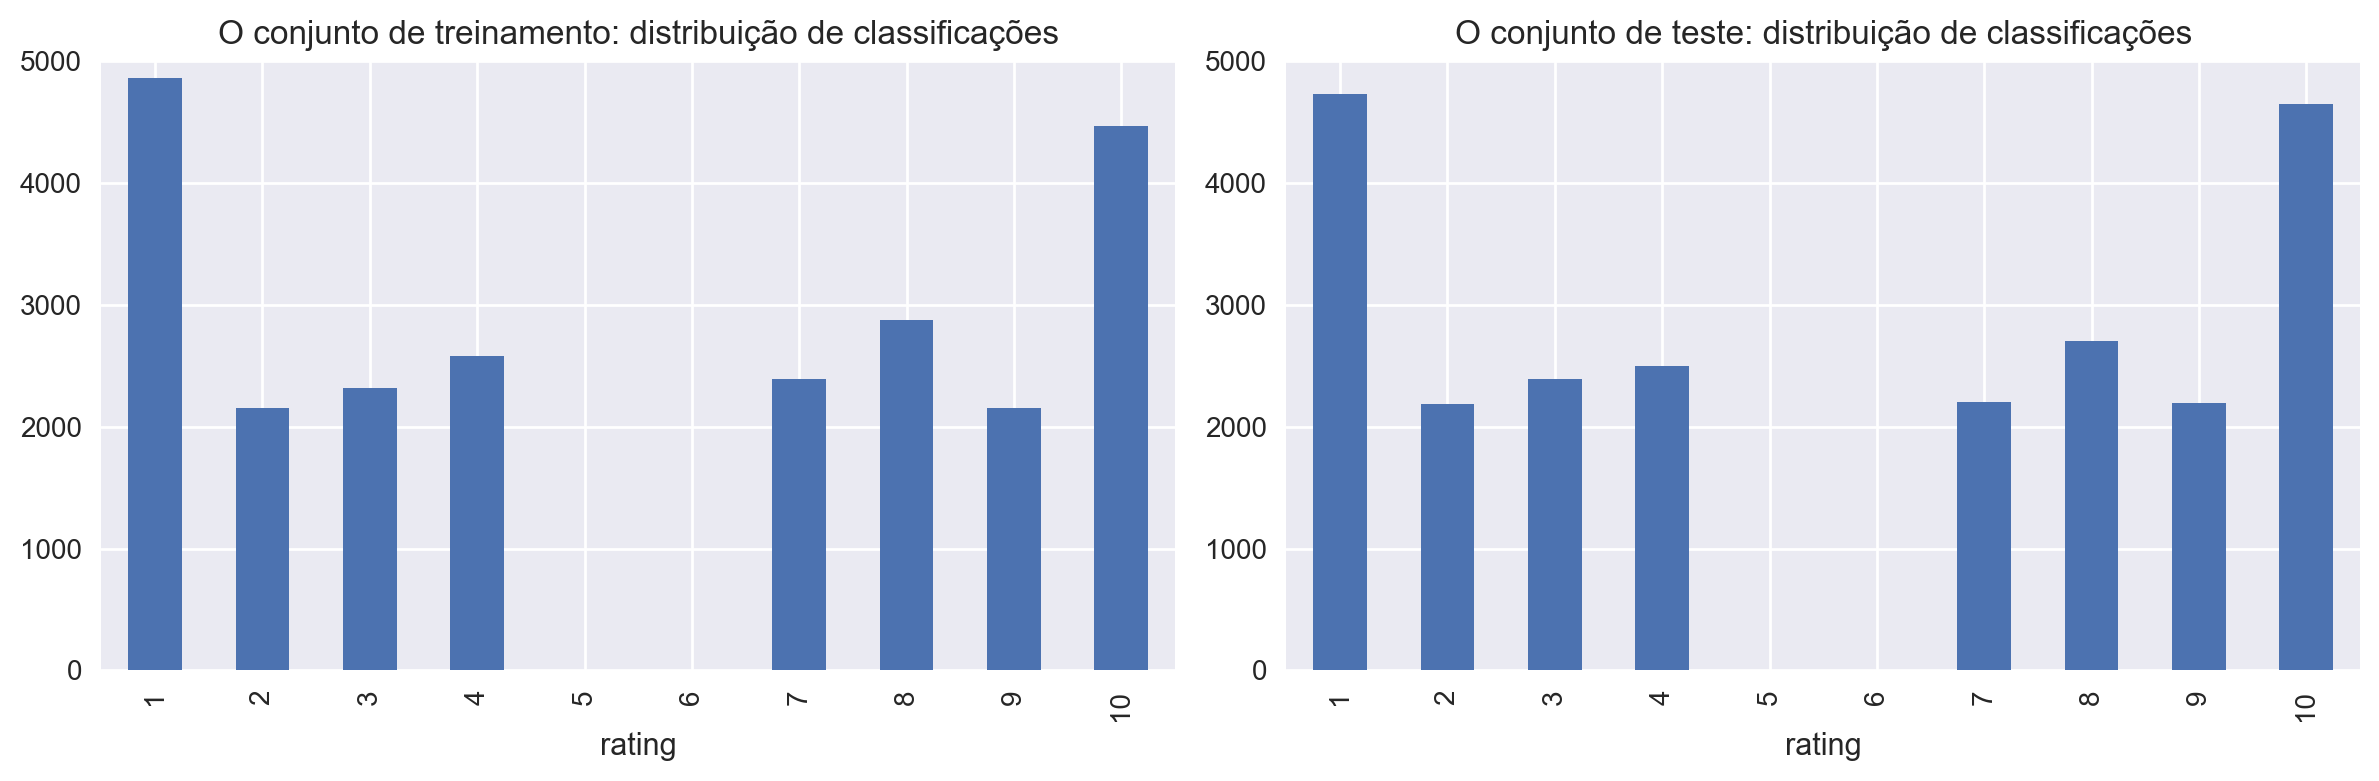

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

C:\Users\ferna\AppData\Local\Temp\ipykernel_16164\1483671763.py:14: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
C:\Users\ferna\AppData\Local\Temp\ipykernel_16164\1483671763.py:15: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
C:\Users\ferna\AppData\Local\Temp\ipykernel_16164\1483671763.py:30: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
C:\Users\ferna\AppData\Local\Temp\ipykernel_16164\1483671763.py:31: UserWarning: 

Support for a

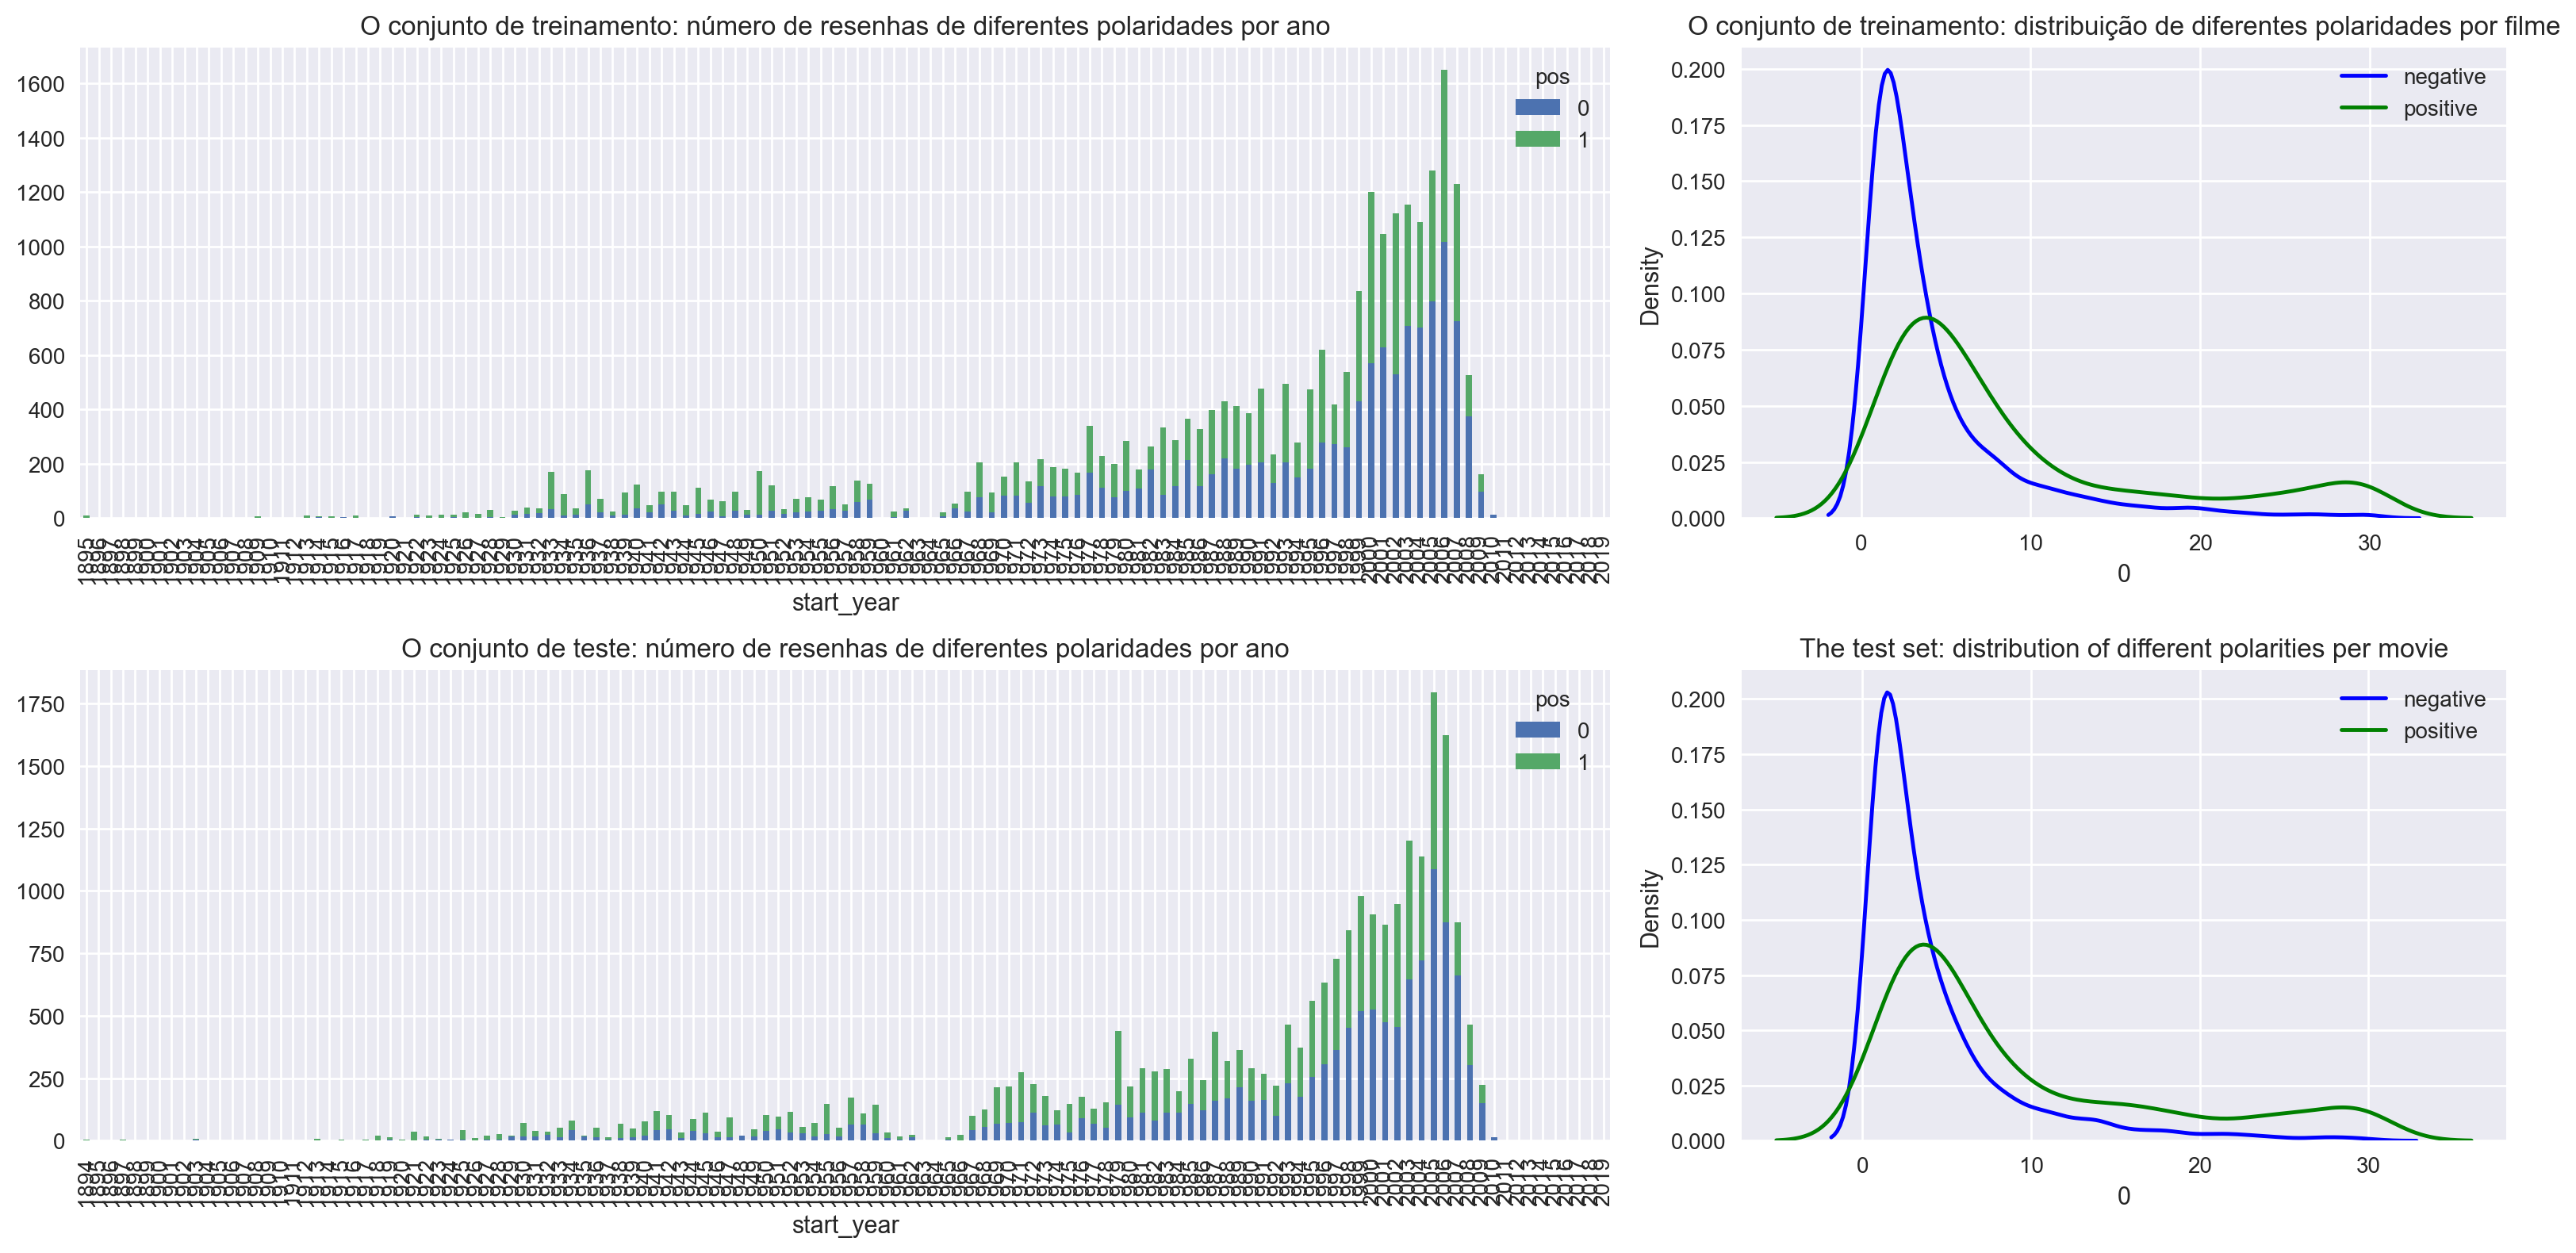

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [11]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        eval_stats[type]['Acurácia'] = metrics.accuracy_score(target, pred_target)
        
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        eval_stats[type]['F1'] = max(f1_scores)
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(3)
    df_eval_stats = df_eval_stats.reindex(index=('Acurácia', 'F1', 'APS', 'ROC AUC'))
    
    
    display(df_eval_stats)
    return df_eval_stats

## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [12]:


def normalize_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\']', ' ', text).strip()
    return text

df_reviews['review_norm'] = df_reviews['review'].progress_apply(normalize_text)
display(df_reviews[['review', 'review_norm']].head())



  0%|          | 0/47331 [00:00<?, ?it/s]

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenti...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in...
4,I'm totally agree with GarryJohal from Singapo...,i'm totally agree with garryjohal from singapo...


## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [13]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_texts = df_reviews_train['review_norm']
test_texts = df_reviews_test['review_norm']
train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Trabalhando com modelos

### Modelo 0 - Constante

In [14]:
from sklearn.dummy import DummyClassifier

,train,test
Acurácia,0.501,0.502
F1,0.666,0.665
APS,0.499,0.498
ROC AUC,0.500,0.500


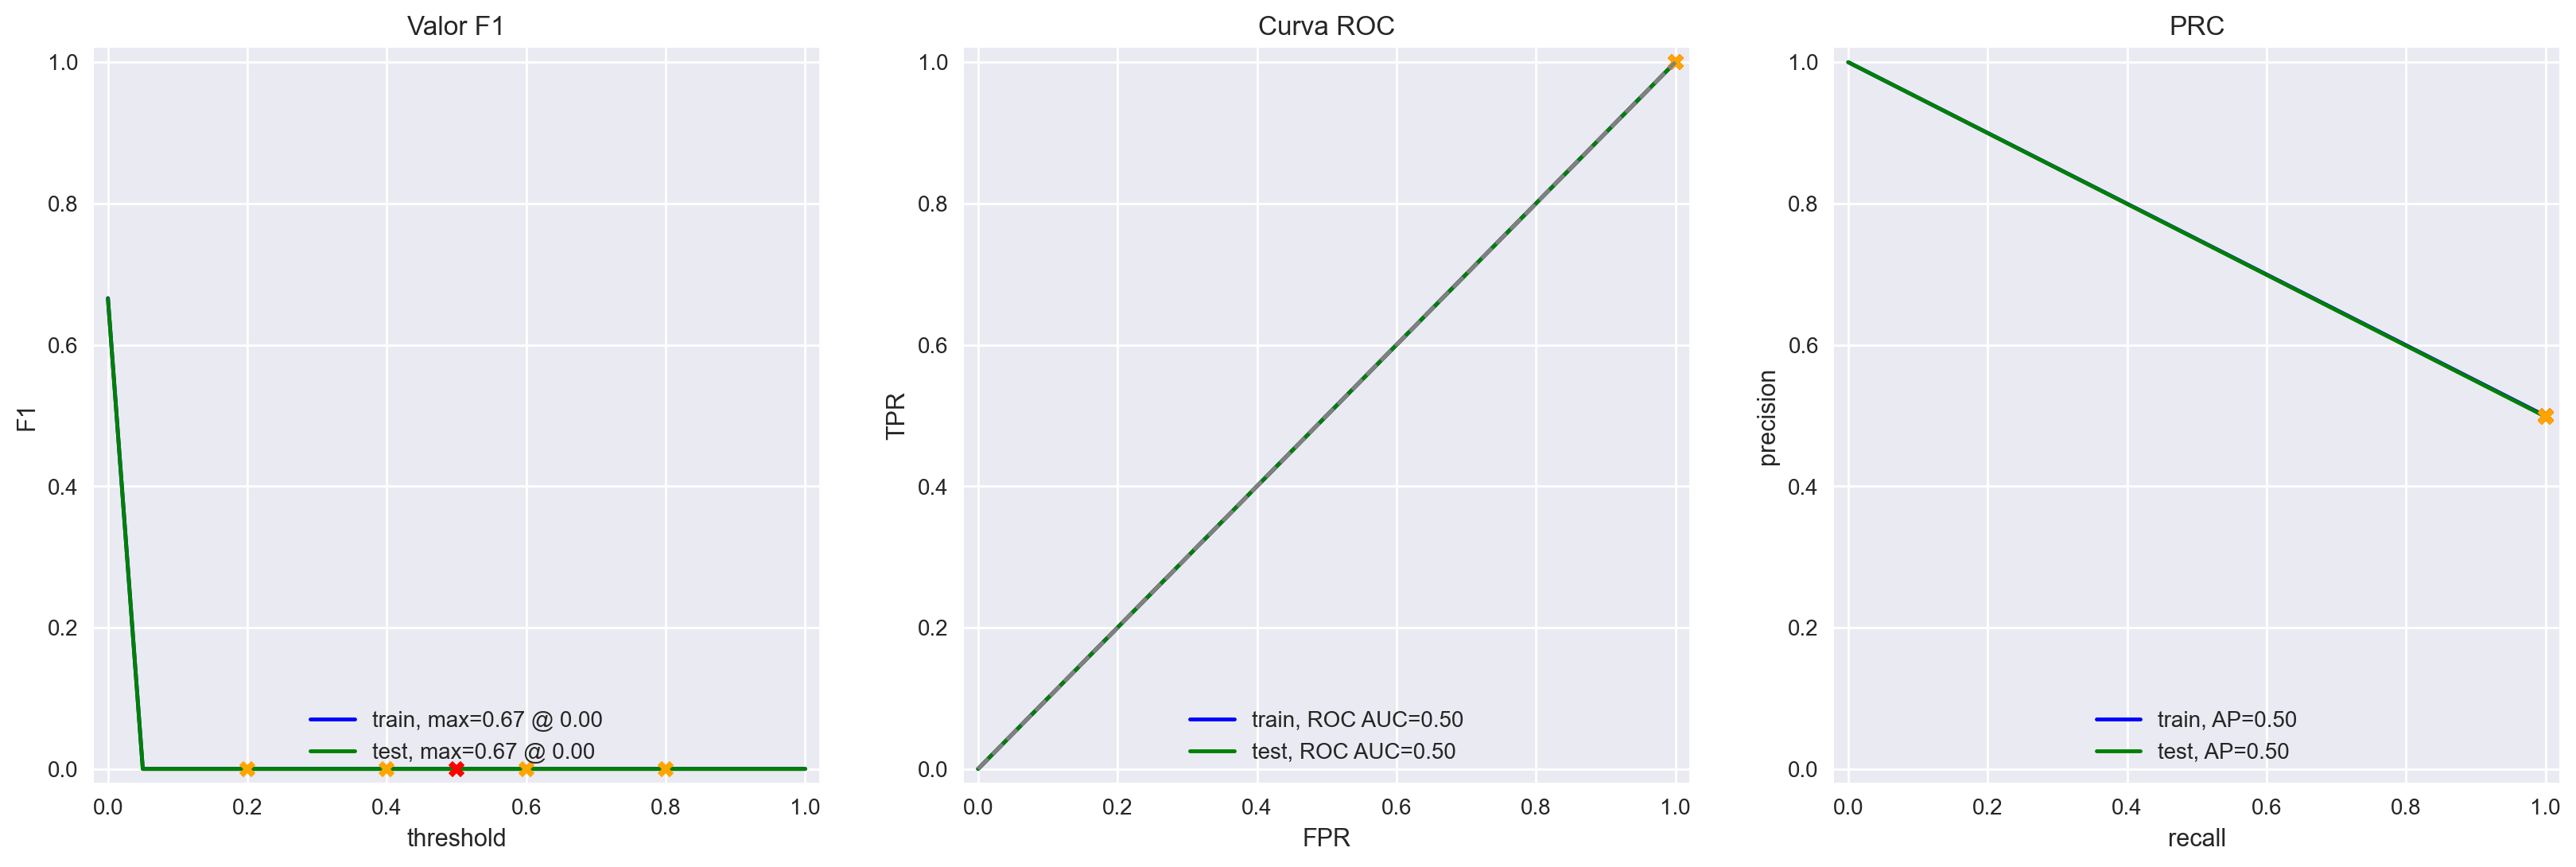

In [15]:
model_dummy = DummyClassifier(strategy='most_frequent')

train_features_dummy = np.zeros((len(train_target), 1))
test_features_dummy = np.zeros((len(test_target), 1))

model_dummy.fit(train_features_dummy, train_target)
results_dummy = evaluate_model(
    model_dummy,
    train_features_dummy,
    train_target,
    test_features_dummy,
    test_target
)


### Modelo 1 - NLTK, TF-IDF e Regressão Linear

TF-IDF

In [16]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [17]:
tfidf_vectorizer_lr = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=4,
    max_df=0.9,
)

train_features_1 = tfidf_vectorizer_lr.fit_transform(train_texts)
test_features_1 = tfidf_vectorizer_lr.transform(test_texts)

model_1 = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model_1.fit(train_features_1, train_target)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

,train,test
Acurácia,0.947,0.881
F1,0.948,0.882
APS,0.988,0.949
ROC AUC,0.988,0.951


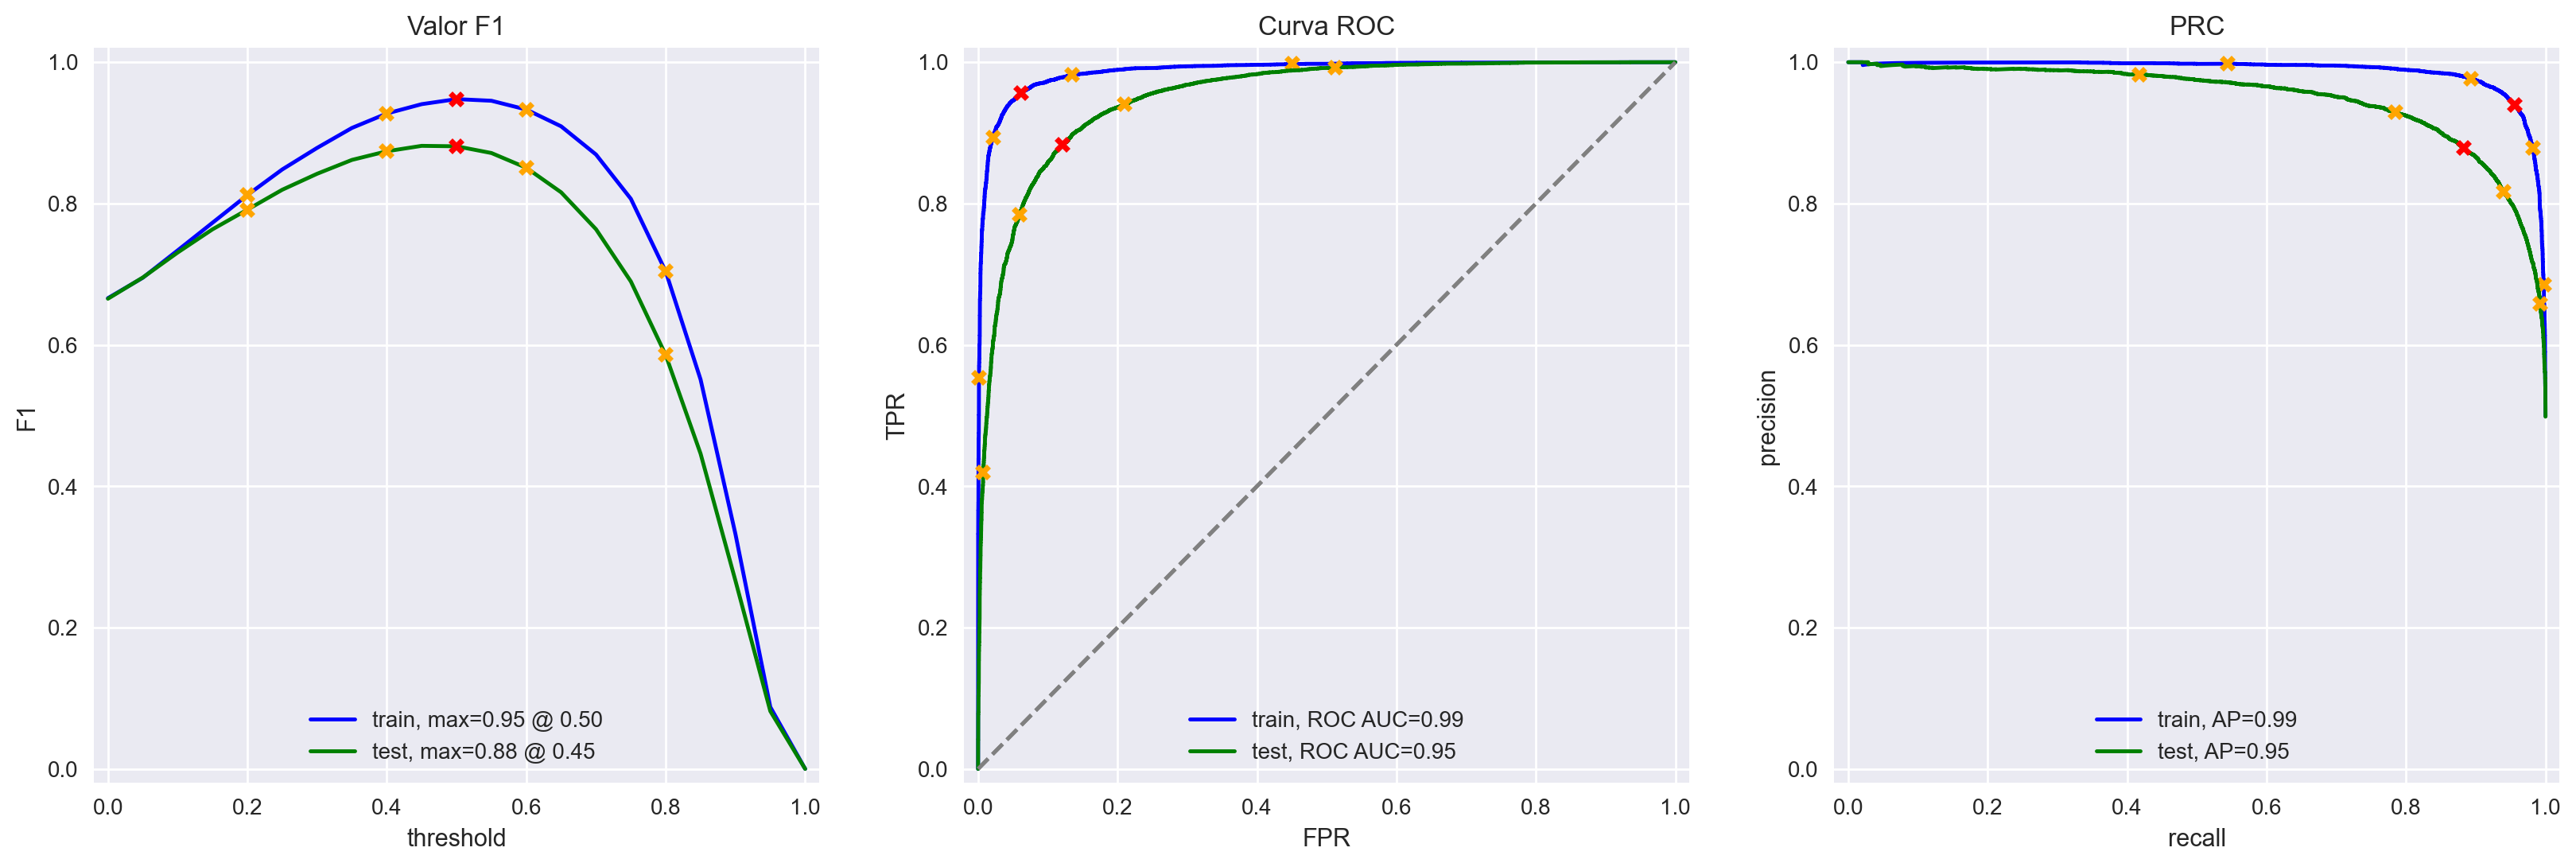

In [18]:
results_lr = evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

### Modelo 2 - spaCy, TF-IDF e Regressão Linear

In [19]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [20]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop]
    #tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

,train,test
Acurácia,0.942,0.876
F1,0.943,0.876
APS,0.986,0.945
ROC AUC,0.985,0.947


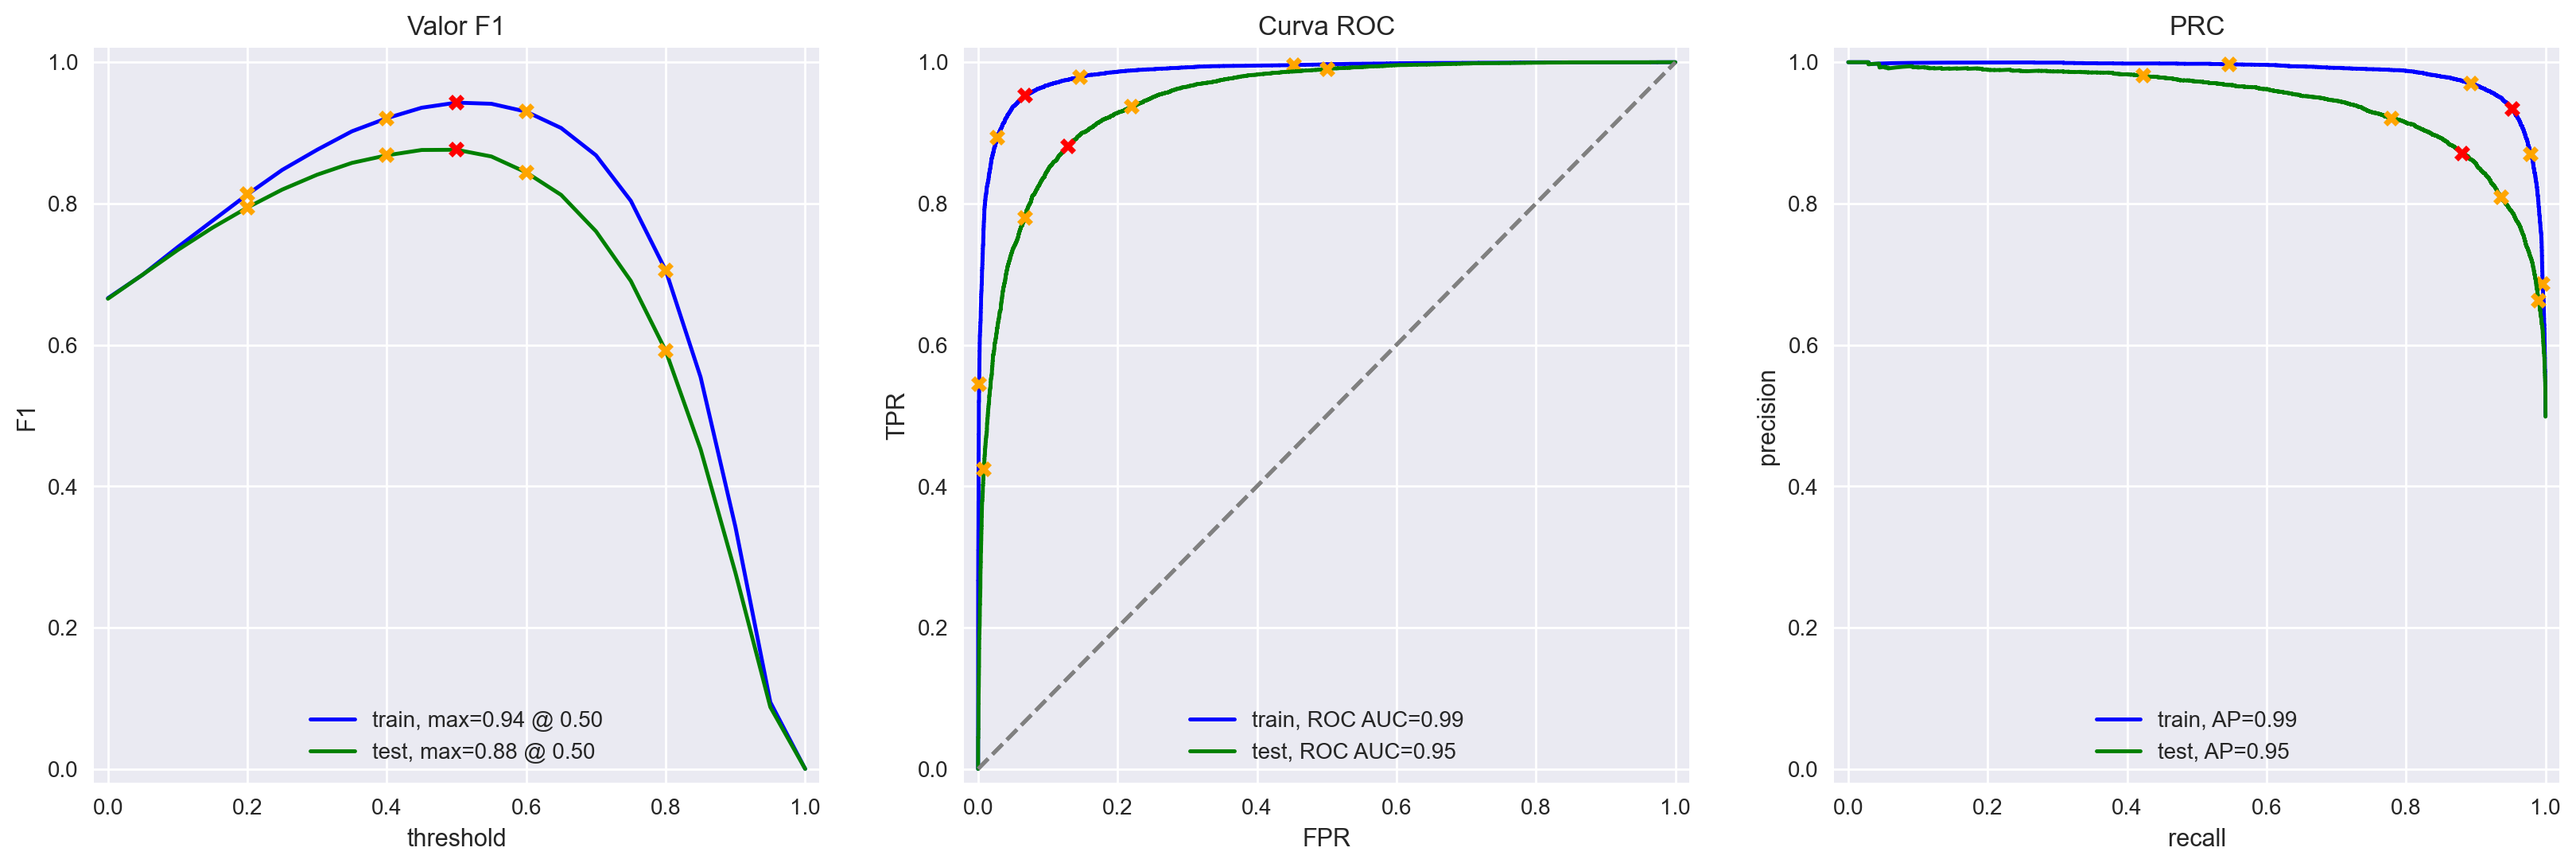

In [21]:
train_texts_spacy = train_texts.progress_apply(text_preprocessing_3)
   
test_texts_spacy = test_texts.progress_apply(text_preprocessing_3)

tfidf_vectorizer_spacy = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=4,
    max_df=0.9,
)
train_features_spacy = tfidf_vectorizer_spacy.fit_transform(train_texts_spacy)
test_features_spacy = tfidf_vectorizer_spacy.transform(test_texts_spacy)

model_spacy_lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model_spacy_lr.fit(train_features_spacy, train_target)
results_spacy_lr = evaluate_model(
    model_spacy_lr,
    train_features_spacy,
    train_target,
    test_features_spacy,
    test_target,
)




### Modelo 3 - SpaCy, TF-IDF e LGBMClassifier

In [22]:
from lightgbm import LGBMClassifier

[LightGBM] [Info] Number of positive: 11884, number of negative: 11912
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.866438 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 542107
[LightGBM] [Info] Number of data points in the train set: 23796, number of used features: 15890
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499412 -> initscore=-0.002353
[LightGBM] [Info] Start training from score -0.002353


c:\Users\ferna\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ferna\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ferna\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ferna\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,train,test
Acurácia,0.935,0.863
F1,0.936,0.866
APS,0.985,0.937
ROC AUC,0.985,0.940


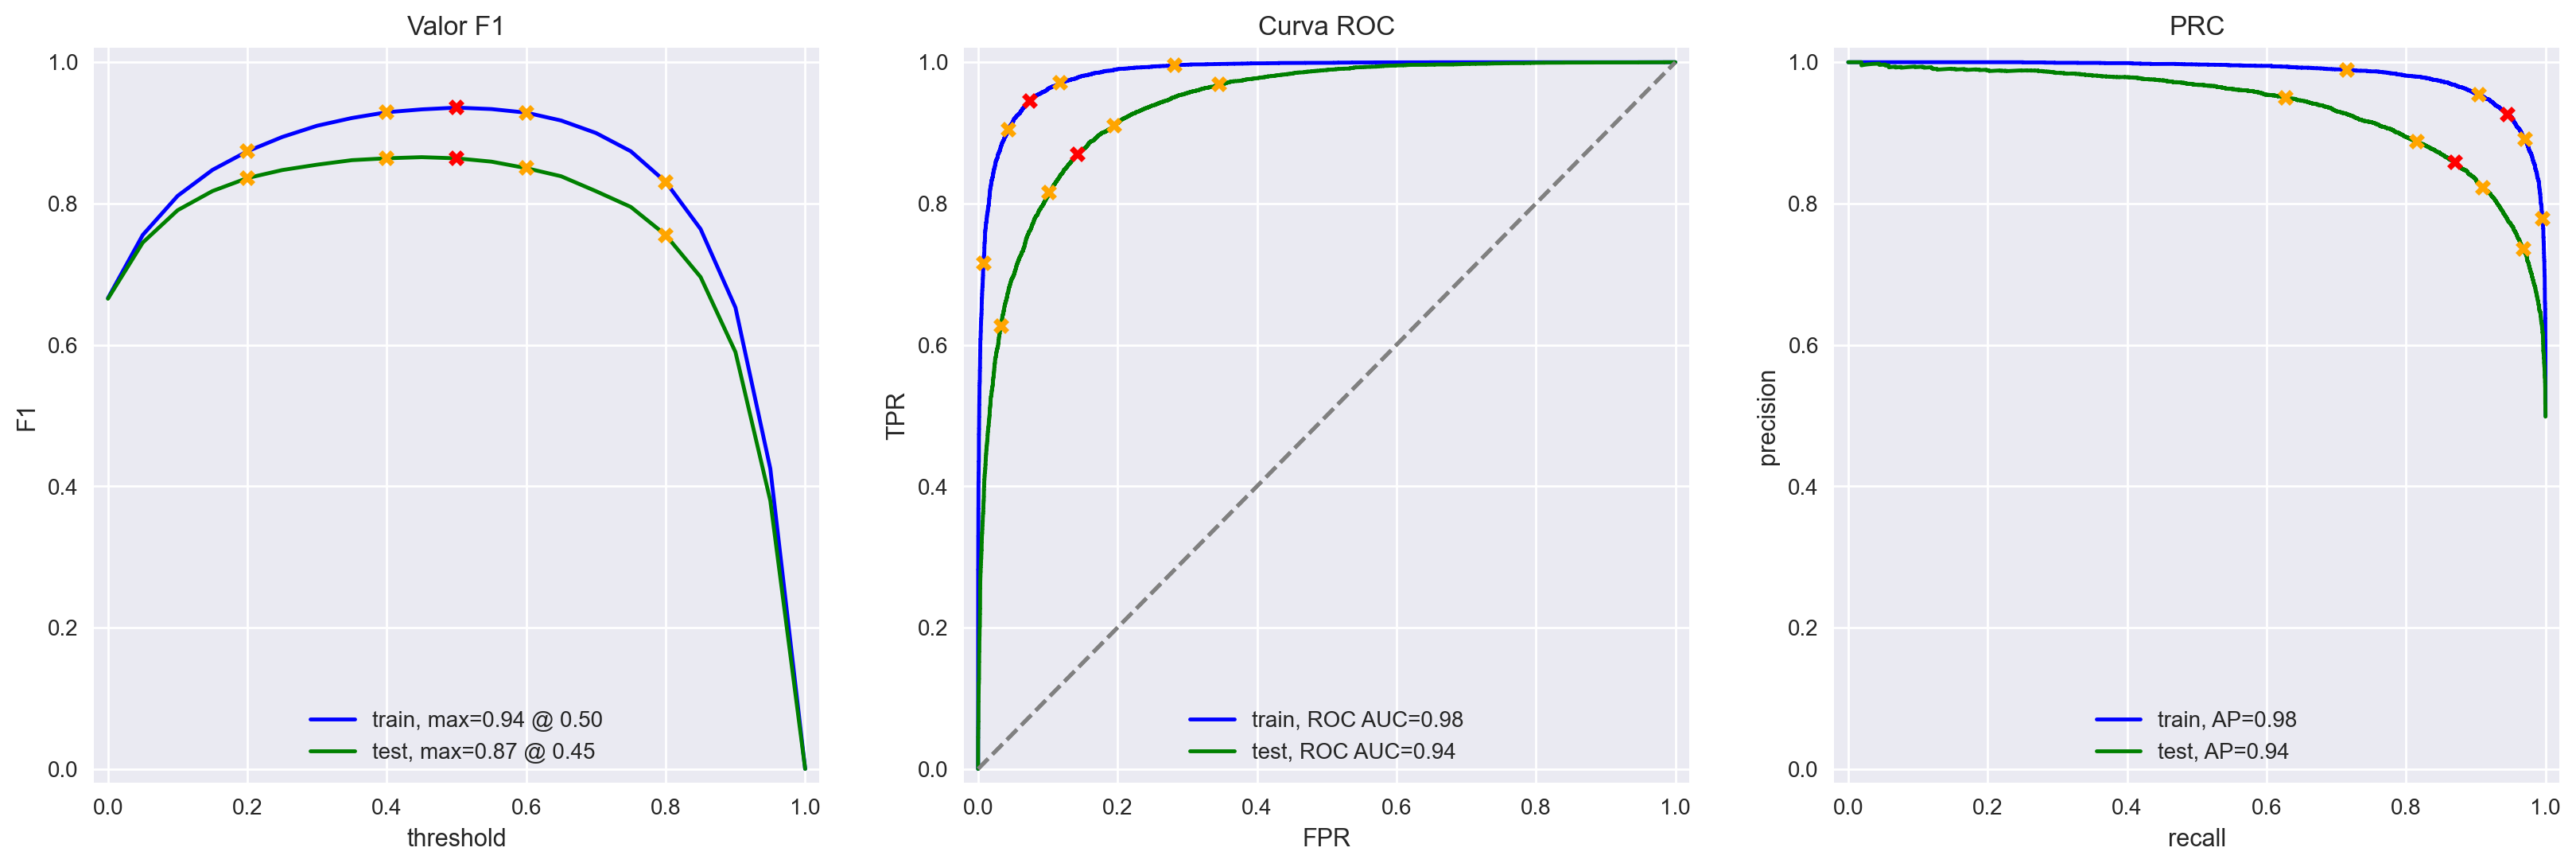

In [23]:
model_spacy_lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
)
model_spacy_lgbm.fit(train_features_spacy, train_target)
results_spacy_lgbm = evaluate_model(
    model_spacy_lgbm,
    train_features_spacy,
    train_target,
    test_features_spacy,
    test_target,
)




###  Modelo 4 - BERT

In [24]:
import torch
import transformers

In [25]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
def BERT_text_to_embeddings(texts, max_length=64, batch_size=100, force_device=None, disable_progress_bar=False):
    
    encoded = tokenizer(
        list(texts),
        add_special_tokens=True,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_attention_mask=True,
        return_tensors='np',
    )

    ids_list = encoded['input_ids']
    attention_mask_list = encoded['attention_mask']

    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Usando o dispositivo {device}.')

    model.to(device)
    model.eval()
    if not disable_progress_bar:
        print(f'Usando dispositivo: {device}')
    
    # recebendo incorporações em lotes


    embeddings = []
    total_batches = math.ceil(len(ids_list) / batch_size)

    for i in tqdm(range(total_batches), disable=disable_progress_bar):
        start = i * batch_size
        end = (i + 1) * batch_size

        ids_batch = torch.LongTensor(ids_list[start:end]).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_list[start:end]).to(device)

        with torch.no_grad():
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)
        embeddings.append(batch_embeddings.last_hidden_state[:, 0, :].detach().cpu().numpy())

    return np.concatenate(embeddings)

In [27]:
# Atenção! A execução do BERT para milhares de textos pode levar muito tempo na CPU, pelo menos várias horas
#train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cpu')

In [28]:
'''
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)
'''

"\nprint(df_reviews_train['review_norm'].shape)\nprint(train_features_9.shape)\nprint(train_target.shape)\n"

In [29]:
'''
sample_size = 400
train_sample = df_reviews_train.sample(sample_size, random_state=42)
test_sample = df_reviews_test.sample(sample_size, random_state=42)
'''


'\nsample_size = 400\ntrain_sample = df_reviews_train.sample(sample_size, random_state=42)\ntest_sample = df_reviews_test.sample(sample_size, random_state=42)\n'

In [30]:
train_features_bert = BERT_text_to_embeddings(df_reviews_train['review_norm'])

Usando o dispositivo cpu.
Usando dispositivo: cpu


  0%|          | 0/238 [00:00<?, ?it/s]

In [31]:
test_features_bert = BERT_text_to_embeddings(df_reviews_test['review_norm'])

Usando o dispositivo cpu.
Usando dispositivo: cpu


  0%|          | 0/236 [00:00<?, ?it/s]

,train,test
Acurácia,0.788,0.771
F1,0.793,0.785
APS,0.864,0.849
ROC AUC,0.867,0.854


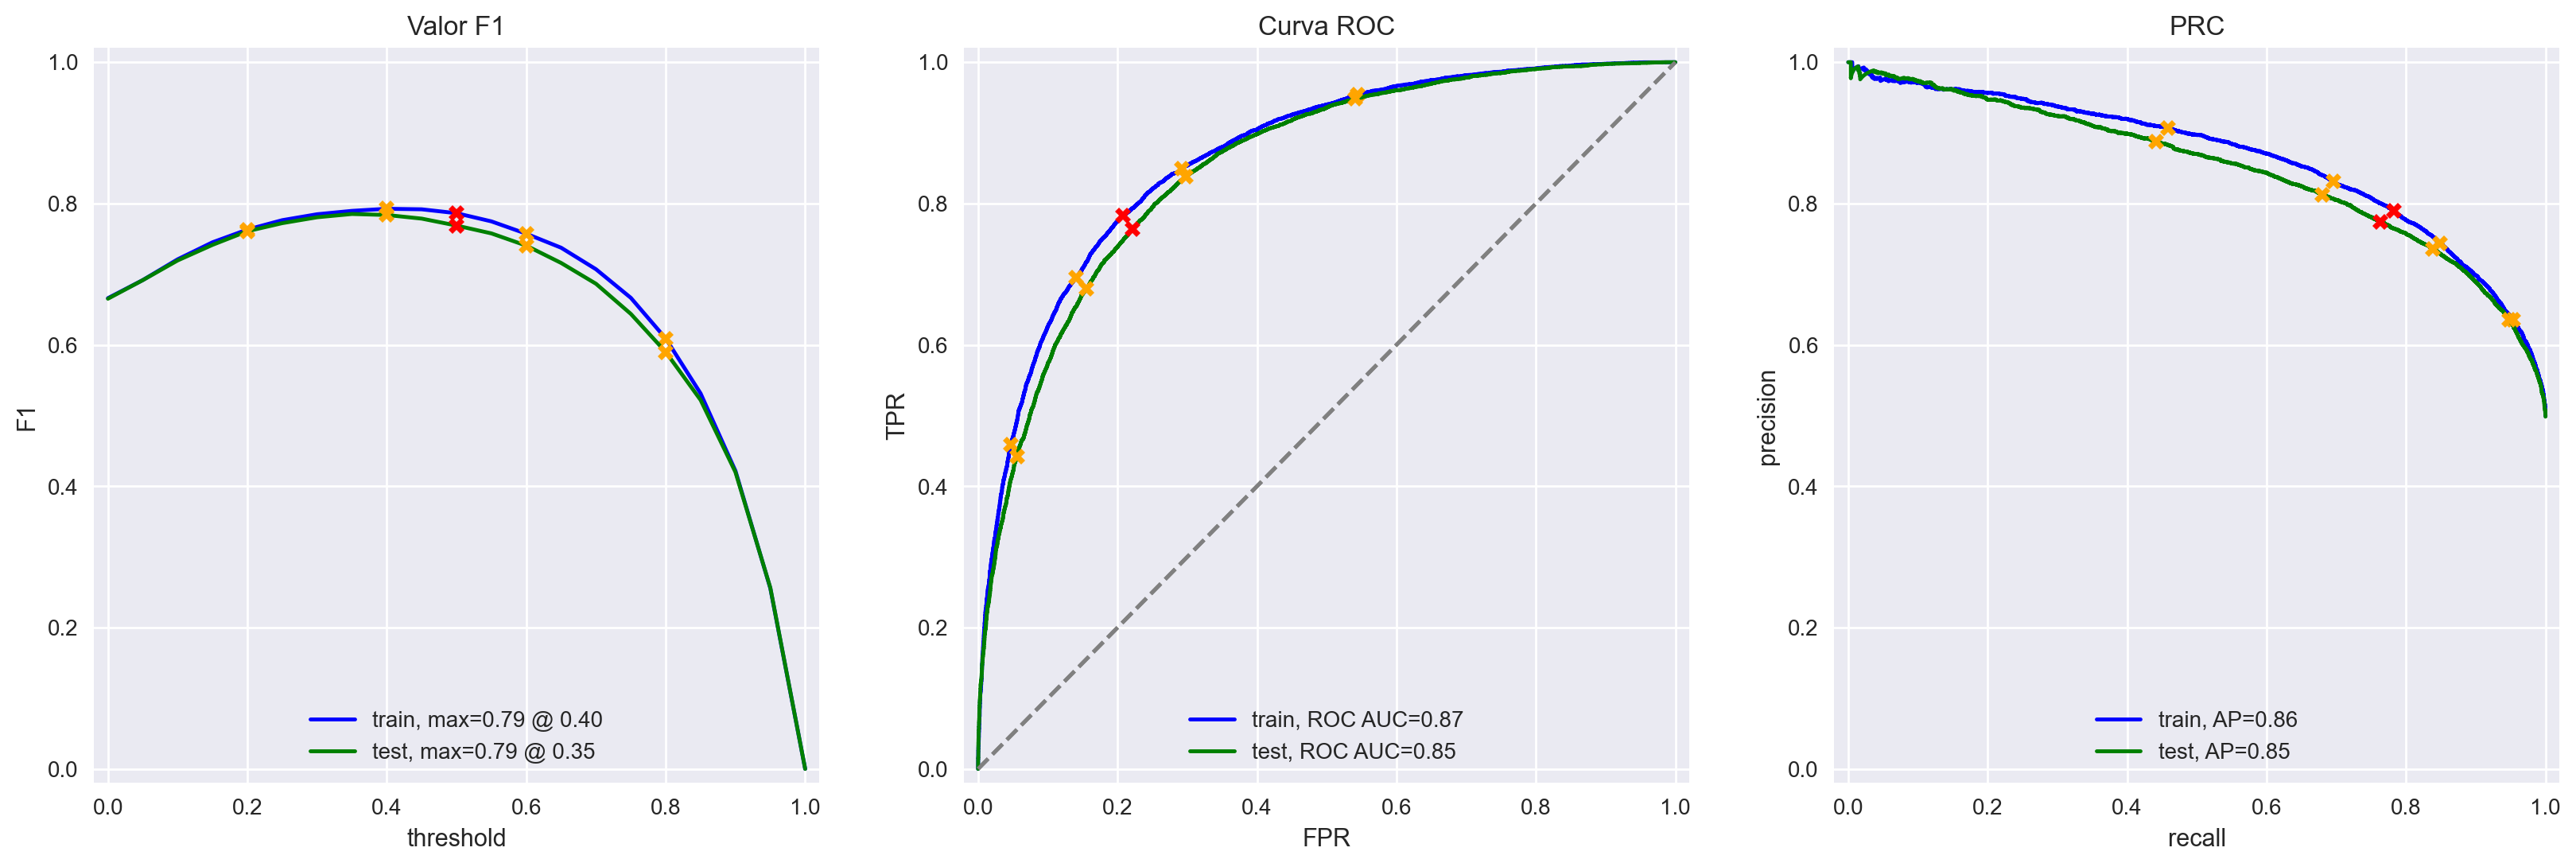

In [32]:
model_bert_lr = LogisticRegression(max_iter=5000, solver='liblinear', random_state=42)
model_bert_lr.fit(train_features_bert, df_reviews_train['pos'])
results_bert = evaluate_model(
    model_bert_lr,
    train_features_bert,
    df_reviews_train['pos'],
    test_features_bert,
    df_reviews_test['pos'],
)



In [33]:
comparison_rows = {
    'dummy': results_dummy['test'],
    'tfidf_lr': results_lr['test'],
    'Bert' : results_bert['test'],
    'spacy_lr': results_spacy_lr['test'],
    'spacy_lgbm': results_spacy_lgbm['test'],
}

comparison_df = pd.DataFrame(comparison_rows).T.sort_values('F1', ascending=False)
display(comparison_df.round(3))


,Acurácia,F1,APS,ROC AUC
tfidf_lr,0.881,0.882,0.949,0.951
spacy_lr,0.876,0.876,0.945,0.947
spacy_lgbm,0.863,0.866,0.937,0.940
Bert,0.771,0.785,0.849,0.854
dummy,0.502,0.665,0.498,0.500


In [34]:
# se você tiver as incorporações, é aconselhável salvá-las para tê-las prontas se 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# e carregar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

## Minhas Resenhas

Como o dataset e os modelos estao em ingles, o ideal e testar reviews manuais tambem em ingles.

In [35]:
# sinta-se à vontade para remover completamente essas resenhas e experimentar seus modelos nas suas próprias resenhas, as abaixo são apenas exemplos


my_reviews = pd.DataFrame([
    'I did not enjoy this movie at all. It was boring and too long.',
    'The plot was weak, but the acting was still decent.',
    'I was completely absorbed by the film and would watch it again.',
    'What a mess. Bad dialogue, weak characters and a frustrating ending.',
    'A surprisingly warm and clever remake that respects the original.',
    'Not perfect, but overall a solid and enjoyable movie.',
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)
display(my_reviews)

,review,review_norm
0,I did not enjoy this movie at all. It was bori...,i did not enjoy this movie at all it was bori...
1,"The plot was weak, but the acting was still de...",the plot was weak but the acting was still de...
2,I was completely absorbed by the film and woul...,i was completely absorbed by the film and woul...
3,"What a mess. Bad dialogue, weak characters and...",what a mess bad dialogue weak characters and...
4,A surprisingly warm and clever remake that res...,a surprisingly warm and clever remake that res...
5,"Not perfect, but overall a solid and enjoyable...",not perfect but overall a solid and enjoyable...


### Modelo 1- NLTK, TF-IDF e Regressão Linear

In [39]:
texts = my_reviews['review_norm']
my_reviews_pred_prob = model_1.predict_proba(tfidf_vectorizer_lr.transform(texts))[:, 1]

for review, probability in zip(my_reviews['review'], my_reviews_pred_prob):
    print(f'{probability:.3f} -> {review}')

0.176 -> I did not enjoy this movie at all. It was boring and too long.
0.082 -> The plot was weak, but the acting was still decent.
0.493 -> I was completely absorbed by the film and would watch it again.
0.035 -> What a mess. Bad dialogue, weak characters and a frustrating ending.
0.592 -> A surprisingly warm and clever remake that respects the original.
0.966 -> Not perfect, but overall a solid and enjoyable movie.


### Modelo 2 - spaCy, TF-IDF e Regressão Linear

In [36]:
texts = my_reviews['review_norm']
texts_spacy = texts.apply(text_preprocessing_3)
my_reviews_pred_prob_spacy = model_spacy_lr.predict_proba(tfidf_vectorizer_spacy.transform(texts_spacy))[:, 1]
for review, probability in zip(my_reviews['review'], my_reviews_pred_prob_spacy):
    print(f'{probability:.3f} -> {review}')

0.358 -> I did not enjoy this movie at all. It was boring and too long.
0.089 -> The plot was weak, but the acting was still decent.
0.408 -> I was completely absorbed by the film and would watch it again.
0.028 -> What a mess. Bad dialogue, weak characters and a frustrating ending.
0.574 -> A surprisingly warm and clever remake that respects the original.
0.966 -> Not perfect, but overall a solid and enjoyable movie.


### Modelo 3 - SpaCy, TF-IDF e LGBMClassifier

In [37]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_spacy_lgbm.predict_proba(tfidf_vectorizer_spacy.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.3f}:  {review}')

0.382:  i did not enjoy this movie at all  it was boring and too long
0.162:  the plot was weak  but the acting was still decent
0.651:  i was completely absorbed by the film and would watch it again
0.018:  what a mess  bad dialogue  weak characters and a frustrating ending
0.685:  a surprisingly warm and clever remake that respects the original
0.939:  not perfect  but overall a solid and enjoyable movie


c:\Users\ferna\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Modelo 4 - BERT

In [38]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_bert_lr.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.3f}:  {review}')

0.045:  i did not enjoy this movie at all  it was boring and too long
0.508:  the plot was weak  but the acting was still decent
0.935:  i was completely absorbed by the film and would watch it again
0.265:  what a mess  bad dialogue  weak characters and a frustrating ending
0.985:  a surprisingly warm and clever remake that respects the original
0.802:  not perfect  but overall a solid and enjoyable movie


## Conclusões

- Vários modelos podem ser utilizados para o treinamento com frasees, utilizando a vetorização para comparação.
- Modelos existentes variam dos mais simples aos mais robustos fazendo associassões de palavras.
- Para o meu caso em específico, o modelo mais pesado (BERT), não atingiu a meta mínima de F1 estipulada. A causa provável é o fato de não ter conseguido rodar o código com max_length maior que 64 (tanto na plataforma online quanto no vscode).
- Ainda sobre a dificuldade de utilização, utilizei para parâmetros maiores apenas seções do modelo, mas ainda assim, com menos dados para aprendizagem, o resultado não foi satisfatório.
- Para este caso em específico, mesmo que se um resultado superior fosse obtido, certamente o modelo mais robusto não se faz necessário para atender a métrica. no quadro de resultados vemos que apenas o modelo Dummi (como já era esperado) e o BERT (para estas configurações), não atenderam o requisito. Entretanto, mesmo para este caso o modelo Berto foi de longe o mais demorado.

# Checklist

- [X]  O caderno foi aberto
- [X]  Os dados de texto são carregados e pré-processados para vetorização
- [X]  Os dados de texto são transformados em vetores
- [X]  Os modelos são treinados e testados
- [X]  O limiar da métrica foi atingido
- [X]  Todas as células de código estão organizadas na ordem de sua execução
- [X]  Todas as células de código podem ser executadas sem erros
- [X]  Há conclusões 